#Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

In [ ]:
x,y = make_regression(n_samples = 100 ,n_features =1 , noise = 10 , random_state =14 )

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train ,x_test , y_train , y_test =  train_test_split(x,y,random_state = 13 , test_size = 0.3)

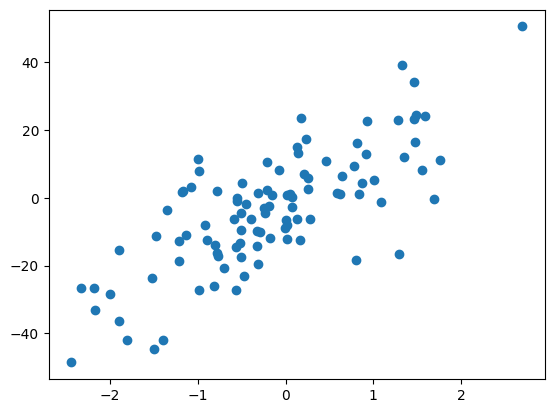

In [ ]:
plt.scatter(x,y)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score , mean_squared_error , mean_absolute_error
from sklearn.preprocessing import OrdinalEncoder ,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

In [ ]:
lr = LinearRegression()

In [ ]:
lr.fit(x_train , y_train)


LinearRegression()

In [ ]:
r2_score(y_test,lr.predict(x_test))

0.6444659144101281

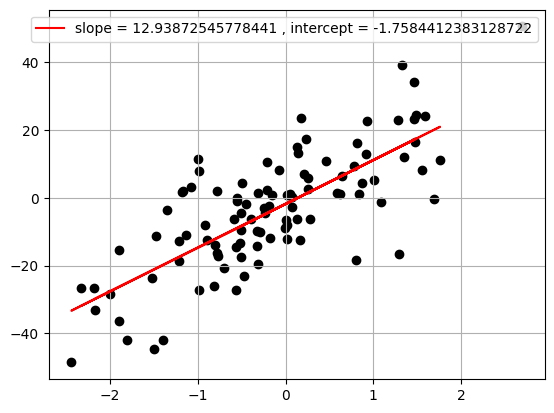

In [ ]:
plt.scatter(x,y , color ='black')
plt.plot(x_test ,lr.predict(x_test), color = 'red' ,label = f'slope = {lr.coef_[0]} , intercept = {lr.intercept_}' )
plt.legend()
plt.grid()
plt.show()


In [ ]:
a  = Ridge(alpha = 1)
a.fit(x_train , y_train)
rd1 = a.predict(x_test)

In [ ]:
b = Ridge(alpha = 10)
b.fit(x_train , y_train)
rd2 = b.predict(x_test)
print(b.coef_)
print(b.intercept_)

[11.32470763]
-1.999630181599401


In [ ]:
c = Ridge(alpha = 50)
c.fit(x_train , y_train)
rd3 = c.predict(x_test)

In [ ]:
d = Ridge(alpha = 100)
d.fit(x_train , y_train)
rd4 = d.predict(x_test)

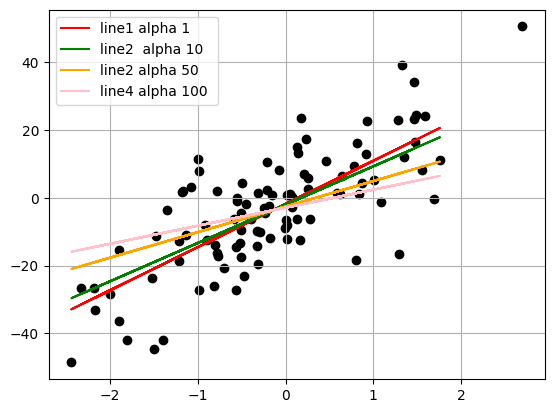

In [ ]:
plt.scatter(x,y , color ='black')
plt.plot(x_test ,rd1, color = 'red' ,label = f"line1 alpha 1" )
plt.plot(x_test ,rd2, color = 'green' ,label = "line2  alpha 10 " )
plt.plot(x_test ,rd3, color = 'orange' ,label = "line2 alpha 50 " )
plt.plot(x_test ,rd4, color = 'pink' ,label = "line4 alpha 100 " )
plt.legend()
plt.grid()
plt.show()


In [ ]:
import numpy as np

In [ ]:
class OwnRidge:
  def __init__(self , alpha ):
    self.alpha = alpha
    self.intercept = None
    self.coef = None
  def fit(self , x_train , y_train) :
    # for coef
    x_train = x_train.ravel()
    y_train =  y_train.ravel()
    ybar = np.mean(y_train)
    xbar =  np.mean(x_train)
    xi_xbar = x_train - xbar
    yi_ybar  = y_train - ybar
    self.coef= np.sum((xi_xbar)*(yi_ybar)) / (self.alpha + np.sum((xi_xbar)**2))
    self.intercept = ybar - (self.coef*xbar)
    print(self.coef)
    print(self.intercept)

In [ ]:
rd = OwnRidge(10)

In [ ]:
rd.fit(x_train , y_train)

11.324707629305568
-1.9996301815994015


In [ ]:
from sklearn.datasets import make_regression
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

In [ ]:
x,y = load_diabetes(return_X_y=True)

In [ ]:
x_train ,x_test , y_train , y_test =  train_test_split(x,y,random_state = 13 , test_size = 0.3)

In [ ]:
from sklearn.linear_model import Ridge
rd = Ridge(alpha= 0.1 , solver  = 'cholesky') # cholesky means your loss fun is ordinary least square(ols), it has other options like gradeint descent too


In [ ]:
rd.fit(x_train , y_train)

Ridge(alpha=0.1, solver='cholesky')

In [ ]:
r2_score(y_test,rd.predict(x_test))

0.4508989510462177

In [ ]:
print(rd.coef_)
print(rd.intercept_)

[  -2.94536746 -222.04694288  515.11902653  346.27911006  -73.48621264
 -132.32693091 -186.09213848  102.46624342  445.25083316  106.14374981]
150.9634372730018


In [ ]:
import numpy as np

class L2Ols:
  def __init__(self , alpha):
    self.alpha = alpha
    self.coef = None
    self.intercept = None

  def fit(self, x_train, y_train):
    x_train = np.insert(x_train, 0, 1, axis=1)  # Add bias term
    y_train = y_train.reshape(-1, 1)
    transpose_x = np.transpose(x_train)
    Xtranspose_x = np.dot(transpose_x, x_train)
    identity_matrix = self.alpha * np.identity(x_train.shape[1])  # Identity matrix includes bias term
    first_term = np.linalg.inv(Xtranspose_x + identity_matrix)
    second_term = np.dot(transpose_x, y_train)

    # Coefficients include intercept
    coef_with_intercept = np.dot(first_term, second_term).flatten()

    # Separate intercept and coefficients
    self.intercept = coef_with_intercept[0]
    self.coef = coef_with_intercept[1:]

    print("Coefficients:", self.coef)
    print("Intercept:", self.intercept)



In [ ]:
l2 = L2Ols(alpha = 0.1)
l2.fit(x_train , y_train)

Coefficients: [  -2.96839813 -222.05407722  515.12749276  346.28512043  -73.4557631
 -132.23900426 -186.14620883  102.42129599  445.26476417  106.12542164]
Intercept: 150.91405756590467


In [ ]:
import numpy as np

In [ ]:
class GdL2:
  def __init__(self, learning_rate, epochs, alpha):
    self.alpha = alpha
    self.learning_rate = learning_rate
    self.epochs = epochs
    self.coef = None
    self.intercept = None

  def fit(self, x_train, y_train):
    x_train = np.insert(x_train, 0, 1, axis=1)
    x_transpose = np.transpose(x_train)
    y_train = y_train.reshape(-1, 1)
    w = np.ones((x_train.shape[1], 1))

    for i in range(self.epochs):
      # Compute predictions
      y_pred = np.dot(x_train, w)

      # Compute gradient with L2 regularization
      gradient = 2 * np.dot(x_transpose, (y_pred - y_train)) + 2 * self.alpha * w
      w = w - self.learning_rate * gradient

    w = w.ravel()
    self.intercept = w[0]
    self.coef = w[1:]
    print(self.intercept)
    print(self.coef)


In [ ]:
gd = GdL2(0.001, 150, 3)  # ✅ Safer and converges smoothly

gd.fit(x_train , y_train)

150.39901437661678
[ 25.86285633  -6.29606162 113.58928865  87.14796953  27.4755769
  15.89051996 -57.0168683   61.79821379  96.27074982  65.44705263]
